# TAEHV 1.5 Encoding and Decoding Demo

This notebook tests streaming encoding & decoding compatibility of TAEHV1.5 with the Hunyuan 1.5 VAE.

## Video Downloading

In [19]:
!python3 -m pip install --quiet yt-dlp


[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [20]:
!yt-dlp --no-warnings 'https://www.youtube.com/shorts/LLXK7ub_QWQ' -o big_cake

[youtube] Extracting URL: https://www.youtube.com/shorts/LLXK7ub_QWQ
[youtube] LLXK7ub_QWQ: Downloading webpage
[youtube] LLXK7ub_QWQ: Downloading android sdkless player API JSON
[youtube] LLXK7ub_QWQ: Downloading web safari player API JSON
[youtube] LLXK7ub_QWQ: Downloading m3u8 information
[info] LLXK7ub_QWQ: Downloading 1 format(s): 399+251
[download] Sleeping 5.00 seconds as required by the site...
[download] Destination: big_cake.f399.mp4
[download] 100% of   16.39MiB in 00:00:00 at 24.80MiB/s;33m00:000m
[download] Destination: big_cake.f251.webm
[download] 100% of  763.02KiB in 00:00:00 at 3.63MiB/s0;33m00:00
[Merger] Merging formats into "big_cake.webm"
Deleting original file big_cake.f399.mp4 (pass -k to keep)
Deleting original file big_cake.f251.webm (pass -k to keep)


In [21]:
!ffmpeg -y -i "big_cake."* -t 2.2 -v quiet -hide_banner -stats \
  -vf "crop=min(iw\,ih):min(iw\,ih),scale=256:256" \
  -c:v libx264 -b:v 5M -pix_fmt yuv420p -an -r 30 \
  small_cake.mp4

frame=   66 fps=0.0 q=-1.0 Lsize=     797KiB time=00:00:02.13 bitrate=3062.2kbits/s dup=0 drop=64 speed=13.2x elapsed=0:00:00.16    


In [22]:
!du -sh small_cake.mp4

800K	small_cake.mp4


In [23]:
from IPython.display import Video, Markdown
import torch as th
import torch.nn as nn

Video("small_cake.mp4", html_attributes="playsinline autoplay loop muted", embed=True)

# Make VAE Testing Code

In [25]:
import cv2

class VideoTensorReader:
    def __init__(self, video_file_path):
        self.cap = cv2.VideoCapture(video_file_path)
        assert self.cap.isOpened(), f"Could not load {video_file_path}"
        self.fps = self.cap.get(cv2.CAP_PROP_FPS)
    def __iter__(self):
        return self
    def __next__(self):
        ret, frame = self.cap.read()
        if not ret:
            self.cap.release()
            raise StopIteration  # End of video or error
        return th.from_numpy(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)).permute(2, 0, 1) # BGR HWC -> RGB CHW

class VideoTensorWriter:
    def __init__(self, video_file_path, width_height, fps=30):
        self.writer = cv2.VideoWriter(video_file_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, width_height)
        assert self.writer.isOpened(), f"Could not create writer for {video_file_path}"
    def write(self, frame_tensor):
        assert frame_tensor.ndim == 3 and frame_tensor.shape[0] == 3, f"{frame_tensor.shape}??"
        self.writer.write(cv2.cvtColor(frame_tensor.permute(1, 2, 0).numpy(), cv2.COLOR_RGB2BGR)) # RGB CHW -> BGR HWC
    def __del__(self):
        if hasattr(self, 'writer'): self.writer.release()

# Load TAEHV1.5, Test

## **Streaming**: Latest Input / Latent / Output

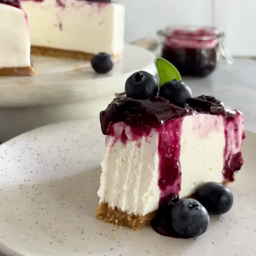

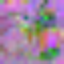

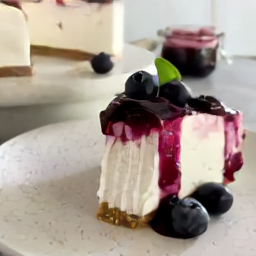

65 Output Frames

frame=   65 fps=0.0 q=-1.0 Lsize=     888KiB time=00:00:02.10 bitrate=3464.2kbits/s speed=20.6x elapsed=0:00:00.10    
taehv_reconstructed_streaming.mp4


## **Non-streaming**

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

65 Output Frames

frame=   65 fps=0.0 q=-1.0 Lsize=     892KiB time=00:00:02.10 bitrate=3478.2kbits/s speed=23.7x elapsed=0:00:00.08    
taehv_reconstructed.mp4


In [29]:
from taehv import TAEHV, StreamingTAEHV
from IPython.display import Markdown, update_display
from PIL import Image
import torchvision.transforms.functional as TF
import time

class Config:
    device = "cuda" if th.cuda.is_available() else ("mps" if th.backends.mps.is_available() else "cpu")
    dtype = th.float16
    
def embed_video(output, output_path):
    writer = VideoTensorWriter(output_path, output.shape[-2:][::-1])
    for frame in output.mul(255.0).round_().byte().cpu().squeeze(0):
        writer.write(frame)
    del writer
    !ffmpeg -y -i {output_path} -v quiet -hide_banner -stats -c:v libx264 -b:v 5M -pix_fmt yuv420p -an {output_path}.compressed.mp4
    print(output_path)
    display(Video(output_path + ".compressed.mp4", html_attributes="playsinline autoplay loop muted controls", embed=True))

@th.no_grad()
def test_vae(vae, video_path="small_cake.mp4", output_path="small_cake_reconstructed.mp4", device=Config.device, dtype=Config.dtype):
    display(Markdown("## **Non-streaming**"))
    video = th.stack(list(VideoTensorReader(video_path)), 0)[None].to(device, dtype).div_(255.0) # NTCHW [0, 1]
    # encode
    latent = vae.encode_video(video, parallel=True)
    # decode
    output = vae.decode_video(latent, parallel=True)
    # display
    display(Markdown(f"{output.shape[1]} Output Frames"))
    embed_video(output, output_path)
    
@th.no_grad()
def test_vae_streaming(vae, video_path="small_cake.mp4", output_path="small_cake_reconstructed.mp4", device=Config.device, dtype=Config.dtype):
    streaming_vae = StreamingTAEHV(vae)
    # initialize display
    display(Markdown("## **Streaming**: Latest Input / Latent / Output"))
    disp_input, disp_latent, disp_output = (display(Image.new("RGB", (256, 256)), display_id=True) for _ in range(3))
    output_frames = []
    # feed one frame at a time, collect outputs as they appear
    for frame_cpu in VideoTensorReader(video_path):
        disp_input.update(TF.to_pil_image(frame_cpu))
        latent = streaming_vae.encode(frame_cpu[None, None].to(device, dtype).div_(255.0))
        if latent is not None:
            disp_latent.update(TF.resize(TF.to_pil_image(latent[0, 0, :3].mul(0.25).add(0.5).clamp(0, 1)), 64))
        decoded = streaming_vae.decode(latent)
        if decoded is not None:
            disp_output.update(TF.to_pil_image(decoded[0, 0]))
            output_frames.append(decoded)
    # flush remaining frames individually so we can show them in the output
    for frame in streaming_vae.flush():
        disp_output.update(TF.to_pil_image(frame[0, 0]))
        output_frames.append(frame)
    # summarize
    display(Markdown(f"{len(output_frames)} Output Frames"))
    embed_video(th.cat(output_frames, 1), output_path)

taehv = TAEHV("taehv1_5.pth").to(Config.device, Config.dtype).eval().requires_grad_(False)
test_vae_streaming(taehv, output_path="taehv_reconstructed_streaming.mp4")
test_vae(taehv, output_path="taehv_reconstructed.mp4")